# OULAD Student Performance and VLE Impact

## Main Question
This notebook answers one question: **How does VLE behavior affect student performance?**

We keep a full modeling pipeline, but the explanation is simple and focused on the VLE impact story.


## Project Scope

- Goal: explain and quantify how VLE engagement links to pass/fail outcomes.
- Data work: load, clean, and engineer VLE-centered features with clear summaries.
- Modeling: compare Logistic Regression, Decision Tree, H2O AutoML, and XGBoost.
- Output style: short, plain explanations and compact visuals only.


## Input: Setup and Configuration
All imports and environment initialization (including H2O) are defined here.


In [1]:
# --- Setup and configuration
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, log_loss

import optuna
import xgboost as xgb

# Optional H2O import (fallback enabled if unavailable)
H2O_AVAILABLE = True
try:
    import h2o
    from h2o.automl import H2OAutoML
except Exception:
    H2O_AVAILABLE = False

pd.set_option('display.max_columns', 200)
np.random.seed(42)

# Runtime config
TEST_MODE = True  # quick run mode
AUTOML_MAX_MODELS = 20
AUTOML_MAX_RUNTIME_SECS = 5400  # 1.5 hours
XGB_TRIALS = 10
XGB_EARLY_STOPPING_ROUNDS = 50

if TEST_MODE:
    AUTOML_MAX_MODELS = 1
    AUTOML_MAX_RUNTIME_SECS = 300
    XGB_TRIALS = 1

os.makedirs('h2o_logs', exist_ok=True)

# Initialize H2O if possible
H2O_READY = False
if H2O_AVAILABLE:
    try:
        h2o.init(max_mem_size='6G', log_dir='./h2o_logs', log_level='WARN', nthreads=-1)
        H2O_READY = True
        print('H2O initialized.')
    except Exception as e:
        print(f'H2O unavailable at runtime: {type(e).__name__}: {e}')
        print('Using fallback model for the AutoML stage.')
else:
    print('H2O package not available. Using fallback model for the AutoML stage.')


H2O package not available. Using fallback model for the AutoML stage.


C:\Users\ento3\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Loading and Cleaning
This section loads all OULAD tables, applies basic cleaning rules, and shows compact summaries only.

Why it matters: clean inputs make the VLE impact analysis reliable.


In [2]:
# CHANGE THIS to your local folder containing the 7 OULAD CSV files
DEFAULT_DATA_DIR = os.path.join('.', 'data')

required_files = [
    'assessments.csv','courses.csv','studentAssessment.csv','studentInfo.csv',
    'studentRegistration.csv','studentVle.csv','vle.csv'
]

# Resolve DATA_DIR from common locations
candidate_dirs = [DEFAULT_DATA_DIR, '.']
resolved = None
for d in candidate_dirs:
    if all(os.path.exists(os.path.join(d, f)) for f in required_files):
        resolved = d
        break

if resolved is None:
    missing = [f for f in required_files if not os.path.exists(os.path.join(DEFAULT_DATA_DIR, f))]
    print('Missing files in DEFAULT_DATA_DIR:', missing)
    print('DEFAULT_DATA_DIR currently set to:', os.path.abspath(DEFAULT_DATA_DIR))
    print('Also checked:', os.path.abspath('.'))
else:
    DATA_DIR = resolved
    print('Using DATA_DIR:', os.path.abspath(DATA_DIR))


Using DATA_DIR: C:\Users\ento3\Downloads\dbm-project-main\dbm-project-main


In [3]:
def read_csv(name, usecols=None, dtype=None):
    path = os.path.join(DATA_DIR, name)
    return pd.read_csv(path, usecols=usecols, dtype=dtype, low_memory=False)

def preview_df(name, df, key_cols=None):
    # Compact preview: shape + a few key columns + missingness summary
    print(f"\n{name}")
    print('shape:', df.shape)
    if key_cols:
        keep = [c for c in key_cols if c in df.columns][:8]
        if keep:
            print('sample columns:', keep)
            print(df[keep].head(3).to_string(index=False))
    miss = (df.isna().mean() * 100).sort_values(ascending=False)
    miss = miss[miss > 0].head(5)
    if len(miss):
        print('top missing (%):')
        print(miss.round(2).to_string())

# Read small/medium tables fully
assessments = read_csv('assessments.csv')
courses = read_csv('courses.csv')
student_info = read_csv('studentInfo.csv')
student_reg = read_csv('studentRegistration.csv')
student_assess = read_csv('studentAssessment.csv')
vle = read_csv('vle.csv')

# Read the large clickstream table with only needed columns + smaller dtypes
student_vle = read_csv(
    'studentVle.csv',
    usecols=['code_module','code_presentation','id_student','id_site','date','sum_click'],
    dtype={
        'code_module':'category','code_presentation':'category',
        'id_student':'int32','id_site':'int32',
        'date':'int16','sum_click':'int32'
    }
)

# Compact loading summary
overview = pd.DataFrame({
    'table': ['assessments','courses','studentInfo','studentRegistration','studentAssessment','vle','studentVle'],
    'rows': [len(assessments),len(courses),len(student_info),len(student_reg),len(student_assess),len(vle),len(student_vle)],
    'cols': [assessments.shape[1],courses.shape[1],student_info.shape[1],student_reg.shape[1],student_assess.shape[1],vle.shape[1],student_vle.shape[1]]
})
print(overview.to_string(index=False))

preview_df('studentInfo (compact preview)', student_info, ['id_student','code_module','code_presentation','final_result'])


              table     rows  cols
        assessments      206     6
            courses       22     3
        studentInfo    32593    12
studentRegistration    32593     5
  studentAssessment   173912     5
                vle     6364     6
         studentVle 10655280     6

studentInfo (compact preview)
shape: (32593, 12)
sample columns: ['id_student', 'code_module', 'code_presentation', 'final_result']
 id_student code_module code_presentation final_result
      11391         AAA             2013J         Pass
      28400         AAA             2013J         Pass
      30268         AAA             2013J    Withdrawn
top missing (%):
imd_band    3.41


### Cleaning Steps
We fix data types, remove invalid or duplicate records, and keep cleaning transparent with short summaries.


In [4]:
# --- 3.1 assessments: drop known invalid IDs (common in OULAD copies)
invalid_ids = {40087, 40088}
assessments = assessments[~assessments['id_assessment'].isin(invalid_ids)].copy()

# Ensure numeric types where needed
assessments['weight'] = pd.to_numeric(assessments['weight'], errors='coerce')
assessments['date'] = pd.to_numeric(assessments['date'], errors='coerce')

# --- 3.2 studentAssessment: clean score/date
student_assess['score'] = student_assess['score'].replace(['?', '', ' '], np.nan)
student_assess['score'] = pd.to_numeric(student_assess['score'], errors='coerce')
student_assess['date_submitted'] = pd.to_numeric(student_assess['date_submitted'], errors='coerce')
student_assess['is_banked'] = pd.to_numeric(student_assess['is_banked'], errors='coerce').fillna(0).astype(int)

before_assess = len(student_assess)
student_assess = student_assess.dropna(subset=['score']).copy()

# --- 3.3 studentInfo: clean imd_band and normalize age label
student_info['imd_band'] = student_info['imd_band'].replace('?', np.nan)
student_info['age_band'] = student_info['age_band'].replace({'55<=': '>=55'})

# --- 3.4 studentVle: drop duplicates to avoid inflated click counts
before_vle = len(student_vle)
student_vle = student_vle.drop_duplicates().copy()

# Compact cleaning summary
cleaning_summary = pd.DataFrame([
    {'step': 'studentAssessment rows dropped (invalid score)', 'count': before_assess - len(student_assess)},
    {'step': 'studentVle duplicate rows dropped', 'count': before_vle - len(student_vle)},
    {'step': 'studentVle rows after dedup', 'count': len(student_vle)}
])
print(cleaning_summary.to_string(index=False))


                                          step   count
studentAssessment rows dropped (invalid score)     173
             studentVle duplicate rows dropped  787170
                   studentVle rows after dedup 9868110


## Feature Engineering
We build the target and create VLE, assessment, and registration features.

Why it matters: these features connect student behavior in VLE to final outcomes.


In [5]:
# --- 4.1 Create target (binary) from final_result
student_info['final_result_upd'] = student_info['final_result'].replace({
    'Distinction': 'Pass',
    'Withdrawn': 'Fail'
})
student_info = student_info[student_info['final_result_upd'].isin(['Pass','Fail'])].copy()
student_info['final_result_upd_numeric'] = (student_info['final_result_upd'] == 'Pass').astype(int)

# --- 4.2 VLE features (aggregate to student-module-presentation grain)
vle_agg = (
    student_vle
    .groupby(['id_student','code_module','code_presentation'], as_index=False, observed=True)
    .agg(
        total_sum_click=('sum_click','sum'),
        active_days=('date','nunique'),
        distinct_sites=('id_site','nunique')
    )
)

early = student_vle[student_vle['date'] <= 14]
early_agg = (
    early.groupby(['id_student','code_module','code_presentation'], as_index=False, observed=True)
         .agg(early_sum_click=('sum_click','sum'), early_active_days=('date','nunique'))
)

vle_features = vle_agg.merge(early_agg, on=['id_student','code_module','code_presentation'], how='left')
vle_features[['early_sum_click','early_active_days']] = vle_features[['early_sum_click','early_active_days']].fillna(0)

vle_features['early_click_ratio'] = vle_features['early_sum_click'] / vle_features['total_sum_click'].replace(0, np.nan)
vle_features['early_click_ratio'] = vle_features['early_click_ratio'].fillna(0)

vle_features['clicks_per_active_day'] = vle_features['total_sum_click'] / vle_features['active_days'].replace(0, np.nan)
vle_features['clicks_per_active_day'] = vle_features['clicks_per_active_day'].fillna(0)

vle_features['early_clicks_per_active_day'] = vle_features['early_sum_click'] / vle_features['early_active_days'].replace(0, np.nan)
vle_features['early_clicks_per_active_day'] = vle_features['early_clicks_per_active_day'].fillna(0)

vle_features['early_active_ratio'] = vle_features['early_active_days'] / vle_features['active_days'].replace(0, np.nan)
vle_features['early_active_ratio'] = vle_features['early_active_ratio'].fillna(0)

# activity type aggregates
vle_types = student_vle.merge(vle[['id_site','activity_type']], on='id_site', how='left')

vle_type_agg = (
    vle_types.groupby(['id_student','code_module','code_presentation','activity_type'], observed=True)
             .agg(type_clicks=('sum_click','sum'))
             .reset_index()
)

vle_type_pivot = vle_type_agg.pivot_table(
    index=['id_student','code_module','code_presentation'],
    columns='activity_type',
    values='type_clicks',
    fill_value=0
).reset_index()

for col in vle_type_pivot.columns:
    if col not in ['id_student','code_module','code_presentation']:
        vle_type_pivot = vle_type_pivot.rename(columns={col: f'clicks_type_{col}'})

vle_features = vle_features.merge(vle_type_pivot, on=['id_student','code_module','code_presentation'], how='left')

type_cols = [c for c in vle_features.columns if c.startswith('clicks_type_')]
vle_features['distinct_activity_types'] = (vle_features[type_cols] > 0).sum(axis=1)

type_sum = vle_features[type_cols].sum(axis=1).replace(0, np.nan)
type_probs = vle_features[type_cols].div(type_sum, axis=0).fillna(0)
vle_features['activity_entropy'] = -(type_probs * np.log(type_probs + 1e-9)).sum(axis=1)
vle_features['top_type_share'] = type_probs.max(axis=1)

vle_features['log1p_total_sum_click'] = np.log1p(vle_features['total_sum_click'])
vle_features['log1p_early_sum_click'] = np.log1p(vle_features['early_sum_click'])

# Compact engineering summary
print('target rows:', len(student_info))
preview_df('VLE feature set (compact)', vle_features, ['id_student','code_module','code_presentation','total_sum_click','early_sum_click','clicks_per_active_day'])


C:\Users\ento3\AppData\Local\Temp\ipykernel_11524\2321843861.py:50: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  vle_type_pivot = vle_type_agg.pivot_table(


target rows: 32593

VLE feature set (compact)
shape: (29228, 37)
sample columns: ['id_student', 'code_module', 'code_presentation', 'total_sum_click', 'early_sum_click', 'clicks_per_active_day']
 id_student code_module code_presentation  total_sum_click  early_sum_click  clicks_per_active_day
       6516         AAA             2014J             2715            538.0              17.075472
       8462         DDD             2013J              634            308.0              11.321429
       8462         DDD             2014J                9              9.0               9.000000


In [6]:
# --- 4.3 Assessment features: weighted score and overall grade
sa = student_assess.merge(
    assessments[['id_assessment','code_module','code_presentation','assessment_type','weight','date']],
    on='id_assessment', how='left'
)

sa['weighted_score'] = np.where(sa['is_banked'] == 1, 0, sa['score'] * (sa['weight'] / 100.0))
sa['lateness_days'] = sa['date_submitted'] - sa['date']

assess_agg = (
    sa.groupby(['id_student','code_module','code_presentation'], as_index=False, observed=True)
      .agg(
          exam_weighted=('weighted_score', lambda x: x[sa.loc[x.index,'assessment_type'].eq('Exam')].sum()),
          non_exam_weighted=('weighted_score', lambda x: x[~sa.loc[x.index,'assessment_type'].eq('Exam')].sum()),
          mean_score=('score','mean'),
          late_submissions=('lateness_days', lambda s: (s>0).sum())
      )
)

assess_agg['has_exam'] = (assess_agg['exam_weighted'] > 0).astype(int)
assess_agg['has_non_exam'] = (assess_agg['non_exam_weighted'] > 0).astype(int)
assess_agg['overall_grade'] = np.where(
    (assess_agg['has_exam']==1) & (assess_agg['has_non_exam']==1),
    (assess_agg['exam_weighted'] + assess_agg['non_exam_weighted']) / 2.0,
    np.where(assess_agg['has_exam']==1, assess_agg['exam_weighted'], assess_agg['non_exam_weighted'])
)

preview_df('Assessment aggregates (compact)', assess_agg, ['id_student','code_module','code_presentation','exam_weighted','non_exam_weighted','mean_score'])



Assessment aggregates (compact)
shape: (25820, 10)
sample columns: ['id_student', 'code_module', 'code_presentation', 'exam_weighted', 'non_exam_weighted', 'mean_score']
 id_student code_module code_presentation  exam_weighted  non_exam_weighted  mean_score
       6516         AAA             2014J            0.0               63.5   61.800000
       8462         DDD             2013J            0.0               34.9   87.666667
       8462         DDD             2014J            0.0                0.0   86.500000


In [7]:
# --- 4.4 Registration features
student_reg['date_registration'] = pd.to_numeric(student_reg['date_registration'], errors='coerce')
student_reg['date_unregistration'] = pd.to_numeric(student_reg['date_unregistration'], errors='coerce')

reg_features = student_reg[['id_student','code_module','code_presentation','date_registration','date_unregistration']].copy()
reg_features['unregistered_flag'] = reg_features['date_unregistration'].notna().astype(int)

preview_df('Registration features (compact)', reg_features, ['id_student','code_module','code_presentation','date_registration','date_unregistration','unregistered_flag'])



Registration features (compact)
shape: (32593, 6)
sample columns: ['id_student', 'code_module', 'code_presentation', 'date_registration', 'date_unregistration', 'unregistered_flag']
 id_student code_module code_presentation  date_registration  date_unregistration  unregistered_flag
      11391         AAA             2013J             -159.0                  NaN                  0
      28400         AAA             2013J              -53.0                  NaN                  0
      30268         AAA             2013J              -92.0                 12.0                  1
top missing (%):
date_unregistration    69.10
date_registration       0.14


In [8]:
# --- Build final dataset at student-module-presentation grain
final_data = (
    student_info
      .merge(vle_features, on=['id_student','code_module','code_presentation'], how='left')
      .merge(assess_agg, on=['id_student','code_module','code_presentation'], how='left')
      .merge(reg_features, on=['id_student','code_module','code_presentation'], how='left')
      .merge(courses, on=['code_module','code_presentation'], how='left')
)

# Derived registration and engagement ratios
if 'date_registration' in final_data.columns:
    final_data['registered_early_flag'] = (final_data['date_registration'] < 0).astype(int)
    final_data['registration_lead_days'] = (-final_data['date_registration']).clip(lower=0)

if 'date_unregistration' in final_data.columns:
    final_data['unregistered_flag'] = final_data['date_unregistration'].notna().astype(int)

if 'module_presentation_length' in final_data.columns:
    final_data['active_days_ratio'] = final_data['active_days'] / final_data['module_presentation_length'].replace(0, np.nan)
    final_data['active_days_ratio'] = final_data['active_days_ratio'].fillna(0)

print('Final dataset shape:', final_data.shape)
preview_df('Final dataset (compact)', final_data, ['id_student','code_module','code_presentation','final_result_upd','final_result_upd_numeric'])

# Feature-group summary for easy reading
feature_groups = pd.DataFrame([
    {'feature_group': 'VLE volume/intensity', 'examples': 'total_sum_click, early_sum_click, clicks_per_active_day'},
    {'feature_group': 'VLE activity mix', 'examples': 'clicks_type_*, distinct_activity_types, activity_entropy'},
    {'feature_group': 'Registration timing', 'examples': 'date_registration, registration_lead_days, registered_early_flag'},
    {'feature_group': 'Course context', 'examples': 'module_presentation_length, code_module, code_presentation'},
    {'feature_group': 'Assessment presence', 'examples': 'has_exam, has_non_exam'}
])
print('\nFeature groups used in this notebook:')
print(feature_groups.to_string(index=False))


Final dataset shape: (32593, 62)

Final dataset (compact)
shape: (32593, 62)
sample columns: ['id_student', 'code_module', 'code_presentation', 'final_result_upd', 'final_result_upd_numeric']
 id_student code_module code_presentation final_result_upd  final_result_upd_numeric
      11391         AAA             2013J             Pass                         1
      28400         AAA             2013J             Pass                         1
      30268         AAA             2013J             Fail                         0
top missing (%):
date_unregistration    69.10
late_submissions       20.78
overall_grade          20.78
has_non_exam           20.78
mean_score             20.78

Feature groups used in this notebook:
       feature_group                                                         examples
VLE volume/intensity          total_sum_click, early_sum_click, clicks_per_active_day
    VLE activity mix         clicks_type_*, distinct_activity_types, activity_entropy
 Registra

## Exploratory Data Analysis (EDA)
This EDA stays question-driven: **Is VLE impactful to student performance?**

We use **8 question-driven EDA checks**:
1. **EDA 1:** Sanity check and missingness/coverage by outcome.
2. **EDA 2:** Distribution separation (violin + box overlays).
3. **EDA 3:** Dose-response (quartiles/deciles) with Wilson confidence intervals.
4. **EDA 4:** Activity composition differences using click-type shares.
5. **EDA 5:** Diversity behavior (entropy and top-type share).
6. **EDA 6:** Timing by day (0-30) using student-day aggregation.
7. **EDA 7:** Confounder context (module, education, deprivation band).
8. **EDA 8:** Univariate logistic OR forest ranking + summary/caveats.

All sections are guard-railed: if prerequisites are missing, this notebook prints a clear skip message and continues.


### EDA 1 - Sanity Check + Coverage/Missingness by Outcome


EDA rows before per-metric filtering: 32593
EDA features considered: 29
Detected clicks_type_* columns: 20

Global-dropna impact by outcome (report only):
 final_result_upd_numeric  total_rows  kept_rows  dropped_rows  drop_rate_pct
                        0       17208      13846          3362          19.54
                        1       15385      15382             3           0.02


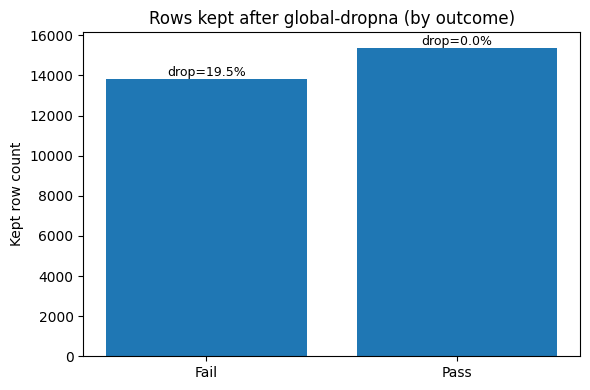


Top 10 features by coverage gap (Pass vs Fail):
                feature  fail_cov_pct  pass_cov_pct  pass_minus_fail_pct  abs_gap_pct
        total_sum_click         80.46         99.98                19.52        19.52
        early_sum_click         80.46         99.98                19.52        19.52
  clicks_per_active_day         80.46         99.98                19.52        19.52
      early_click_ratio         80.46         99.98                19.52        19.52
     early_active_ratio         80.46         99.98                19.52        19.52
distinct_activity_types         80.46         99.98                19.52        19.52
       activity_entropy         80.46         99.98                19.52        19.52
         top_type_share         80.46         99.98                19.52        19.52
   clicks_type_dataplus         80.46         99.98                19.52        19.52
   clicks_type_dualpane         80.46         99.98                19.52        19.52


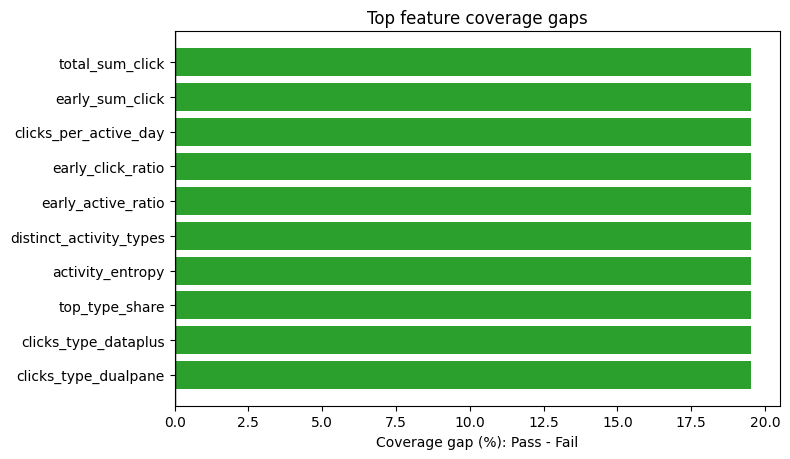

In [9]:
# --- EDA 1: Sanity check + missingness/coverage by outcome
EDA_TARGET = 'final_result_upd_numeric'
if EDA_TARGET not in final_data.columns:
    raise ValueError("Required outcome column 'final_result_upd_numeric' is missing from final_data.")

eda_core = [
    'final_result_upd_numeric',
    'total_sum_click', 'early_sum_click', 'clicks_per_active_day',
    'early_click_ratio', 'early_active_ratio',
    'distinct_activity_types', 'activity_entropy', 'top_type_share'
]
eda_click_cols = [c for c in final_data.columns if c.startswith('clicks_type_')]
eda_features = [c for c in eda_core if c in final_data.columns] + eda_click_cols
eda_features = list(dict.fromkeys(eda_features))

eda_base = final_data[eda_features].copy()
rows_before = len(eda_base)
keep_mask = eda_base.notna().all(axis=1)

tmp = eda_base[[EDA_TARGET]].copy()
tmp['kept'] = keep_mask.astype(int)
impact = (
    tmp.groupby(EDA_TARGET, observed=True)['kept']
       .agg(total_rows='size', kept_rows='sum')
       .reset_index()
)
impact['dropped_rows'] = impact['total_rows'] - impact['kept_rows']
impact['drop_rate_pct'] = np.where(impact['total_rows'] > 0, impact['dropped_rows'] / impact['total_rows'] * 100, np.nan)

print('EDA rows before per-metric filtering:', rows_before)
print('EDA features considered:', len(eda_features))
print('Detected clicks_type_* columns:', len(eda_click_cols))
print('\nGlobal-dropna impact by outcome (report only):')
print(impact.round(2).to_string(index=False))

classes = sorted(pd.Series(tmp[EDA_TARGET].dropna().unique()).astype(int).tolist())
if len(classes) < 2:
    print('skip EDA1 chart: outcome has fewer than 2 classes.')
else:
    labels = ['Pass' if int(v) == 1 else 'Fail' if int(v) == 0 else str(v) for v in impact[EDA_TARGET]]
    plt.figure(figsize=(6, 4))
    bars = plt.bar(labels, impact['kept_rows'])
    plt.title('Rows kept after global-dropna (by outcome)')
    plt.ylabel('Kept row count')
    for b, dr in zip(bars, impact['drop_rate_pct']):
        plt.text(b.get_x() + b.get_width()/2, b.get_height(), f'drop={dr:.1f}%', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

cov_rows = []
for col in [c for c in eda_features if c != EDA_TARGET]:
    by = eda_base.groupby(EDA_TARGET, observed=True)[col].apply(lambda s: s.notna().mean() * 100)
    fail_cov = float(by.get(0, np.nan))
    pass_cov = float(by.get(1, np.nan))
    cov_rows.append({
        'feature': col,
        'fail_cov_pct': fail_cov,
        'pass_cov_pct': pass_cov,
        'pass_minus_fail_pct': pass_cov - fail_cov,
        'abs_gap_pct': abs(pass_cov - fail_cov)
    })

coverage_df = pd.DataFrame(cov_rows)
if coverage_df.empty:
    print('skip EDA1 coverage: no features available.')
    cov_top10 = pd.DataFrame()
else:
    cov_top10 = coverage_df.sort_values('abs_gap_pct', ascending=False).head(10)
    print('\nTop 10 features by coverage gap (Pass vs Fail):')
    print(cov_top10.round(2).to_string(index=False))
    if len(classes) >= 2 and cov_top10['pass_minus_fail_pct'].notna().any():
        p = cov_top10.iloc[::-1]
        plt.figure(figsize=(8, max(4, 0.35 * len(p) + 1.2)))
        plt.barh(p['feature'], p['pass_minus_fail_pct'], color=['#2ca02c' if v >= 0 else '#d62728' for v in p['pass_minus_fail_pct']])
        plt.axvline(0, color='black', linewidth=1)
        plt.xlabel('Coverage gap (%): Pass - Fail')
        plt.title('Top feature coverage gaps')
        plt.tight_layout()
        plt.show()

eda_summary = {'eda1_drop_table': impact.copy(), 'eda1_cov_top10': cov_top10.copy()}


### EDA 2 - Distribution/Separation (Violin + Box Overlay)


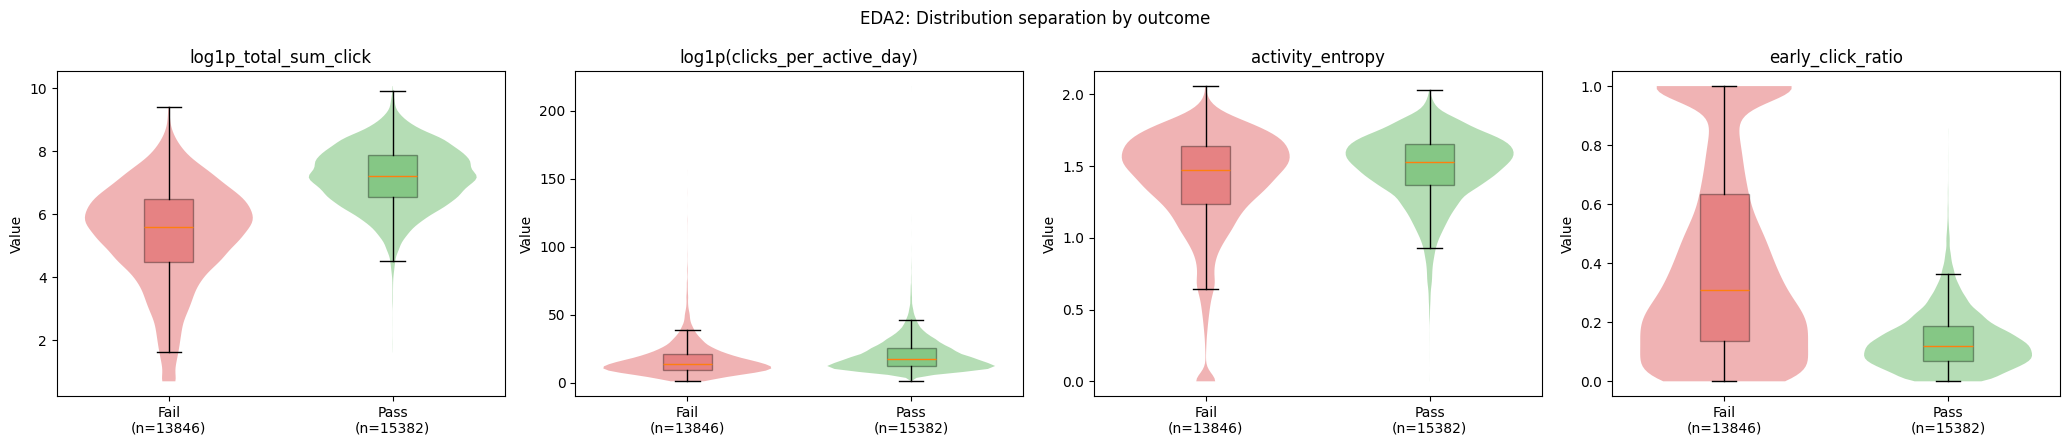

In [10]:
# --- EDA 2: Distribution separation (violin + box), per-metric NA handling
metrics = []
if 'log1p_total_sum_click' in final_data.columns:
    metrics.append(('log1p_total_sum_click', pd.to_numeric(final_data['log1p_total_sum_click'], errors='coerce')))
elif 'total_sum_click' in final_data.columns:
    metrics.append(('log1p(total_sum_click)', np.log1p(pd.to_numeric(final_data['total_sum_click'], errors='coerce').clip(lower=0))))

if 'clicks_per_active_day' in final_data.columns:
    cpd = pd.to_numeric(final_data['clicks_per_active_day'], errors='coerce')
    metrics.append(('log1p(clicks_per_active_day)', np.log1p(cpd.clip(lower=0)) if (cpd >= 0).all(skipna=True) else cpd))

if 'activity_entropy' in final_data.columns:
    metrics.append(('activity_entropy', pd.to_numeric(final_data['activity_entropy'], errors='coerce')))
if 'early_click_ratio' in final_data.columns:
    metrics.append(('early_click_ratio', pd.to_numeric(final_data['early_click_ratio'], errors='coerce')))

if not metrics:
    print('skip EDA2: no required metrics found.')
else:
    fig, axes = plt.subplots(1, len(metrics), figsize=(5.2 * len(metrics), 4.5))
    if len(metrics) == 1:
        axes = [axes]

    drawn = 0
    for ax, (name, series) in zip(axes, metrics):
        d = pd.DataFrame({EDA_TARGET: final_data[EDA_TARGET], 'x': series})
        d = d[d[EDA_TARGET].isin([0, 1])].dropna(subset=['x'])
        fail_vals = d.loc[d[EDA_TARGET] == 0, 'x']
        pass_vals = d.loc[d[EDA_TARGET] == 1, 'x']

        if len(d) < 50:
            print(f'EDA2 warning ({name}): low sample size n={len(d)} (<50).')
        if min(len(fail_vals), len(pass_vals)) < 10:
            print(f'EDA2 warning ({name}): one class is small (Fail={len(fail_vals)}, Pass={len(pass_vals)}).')

        if len(fail_vals) == 0 or len(pass_vals) == 0:
            ax.text(0.5, 0.5, f'{name}\nskip: class missing', ha='center', va='center')
            ax.set_axis_off()
            continue

        vp = ax.violinplot([fail_vals.values, pass_vals.values], positions=[1, 2], widths=0.75, showmeans=False, showextrema=False)
        for b, c in zip(vp['bodies'], ['#d62728', '#2ca02c']):
            b.set_facecolor(c)
            b.set_alpha(0.35)

        bx = ax.boxplot([fail_vals.values, pass_vals.values], positions=[1, 2], widths=0.22, patch_artist=True, showfliers=False)
        for p, c in zip(bx['boxes'], ['#d62728', '#2ca02c']):
            p.set_facecolor(c)
            p.set_alpha(0.35)

        ax.set_xticks([1, 2])
        ax.set_xticklabels([f'Fail\n(n={len(fail_vals)})', f'Pass\n(n={len(pass_vals)})'])
        ax.set_title(name)
        ax.set_ylabel('Value')
        drawn += 1

    if drawn == 0:
        print('skip EDA2: all metrics had insufficient class-separated data.')
        plt.close(fig)
    else:
        plt.suptitle('EDA2: Distribution separation by outcome')
        plt.tight_layout()
        plt.show()


### EDA 3 - Dose-Response (Quartiles + Deciles) with Wilson CI


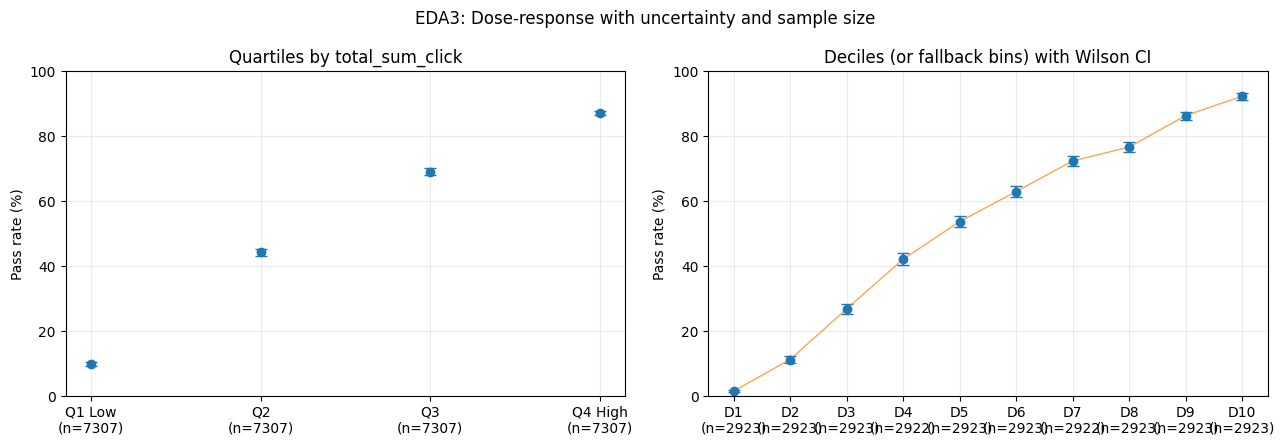

Quartile table:
    bin    n  pass_count  pass_rate_pct  ci_low_pct  ci_high_pct
 Q1 Low 7307         725           9.92        9.26        10.63
     Q2 7307        3235          44.27       43.14        45.41
     Q3 7307        5051          69.13       68.06        70.17
Q4 High 7307        6371          87.19       86.40        87.94

Decile/fallback table:
bin    n  pass_count  pass_rate_pct  ci_low_pct  ci_high_pct
 D1 2923          44           1.51        1.12         2.01
 D2 2923         329          11.26       10.16        12.45
 D3 2923         785          26.86       25.28        28.49
 D4 2922        1231          42.13       40.35        43.93
 D5 2923        1571          53.75       51.93        55.55
 D6 2923        1841          62.98       61.22        64.72
 D7 2922        2116          72.42       70.77        74.01
 D8 2923        2241          76.67       75.10        78.17
 D9 2923        2525          86.38       85.09        87.58
D10 2923        2699     

In [11]:
# --- EDA 3: Dose-response (quartiles + deciles) with Wilson CI

def wilson_ci(k, n, z=1.96):
    if n <= 0:
        return (np.nan, np.nan)
    p = k / n
    den = 1 + (z**2) / n
    cen = (p + (z**2) / (2*n)) / den
    mar = (z / den) * np.sqrt((p*(1-p)/n) + (z**2)/(4*(n**2)))
    return (max(0.0, cen - mar), min(1.0, cen + mar))

metric = 'total_sum_click' if 'total_sum_click' in final_data.columns else ('clicks_per_active_day' if 'clicks_per_active_day' in final_data.columns else None)
eda_summary['eda3_metric'] = metric

if metric is None:
    print('skip EDA3: neither total_sum_click nor clicks_per_active_day exists.')
else:
    d = final_data[[EDA_TARGET, metric]].copy()
    d[metric] = pd.to_numeric(d[metric], errors='coerce')
    d = d[d[EDA_TARGET].isin([0, 1])].dropna(subset=[metric])

    if len(d) < 40:
        print(f'skip EDA3: too few rows for binning (n={len(d)}).')
    else:
        d['rank_metric'] = d[metric].rank(method='first')

        def make_tbl(df, bins, labels):
            z = df.copy()
            z['bin'] = pd.qcut(z['rank_metric'], bins, labels=labels)
            g = z.groupby('bin', observed=True)[EDA_TARGET].agg(n='size', pass_count='sum').reset_index()
            g['pass_rate'] = g['pass_count'] / g['n']
            ci = g.apply(lambda r: wilson_ci(float(r['pass_count']), int(r['n'])), axis=1)
            g['ci_low'] = [c[0] for c in ci]
            g['ci_high'] = [c[1] for c in ci]
            return g

        q_labels = ['Q1 Low', 'Q2', 'Q3', 'Q4 High']
        q_tbl = make_tbl(d, 4, q_labels)

        true_deciles = True
        try:
            d_tbl = make_tbl(d, 10, [f'D{i}' for i in range(1, 11)])
            if len(d_tbl) < 10:
                raise ValueError('collapsed deciles')
        except Exception as e:
            print(f'EDA3 deciles fallback to 4 bins: {type(e).__name__}: {e}')
            d_tbl = make_tbl(d, 4, q_labels)
            true_deciles = False

        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

        def dot_ci(ax, t, title, connect=False):
            x = np.arange(len(t))
            y = t['pass_rate'].values * 100
            yl = (t['pass_rate'] - t['ci_low']).values * 100
            yh = (t['ci_high'] - t['pass_rate']).values * 100
            ax.errorbar(x, y, yerr=[yl, yh], fmt='o', capsize=4)
            if connect:
                ax.plot(x, y, linewidth=1, alpha=0.7)
            ax.set_xticks(x)
            ax.set_xticklabels([f"{b}\n(n={int(n)})" for b, n in zip(t['bin'].astype(str), t['n'])])
            ax.set_ylim(0, 100)
            ax.set_ylabel('Pass rate (%)')
            ax.set_title(title)
            ax.grid(alpha=0.25)

        dot_ci(axes[0], q_tbl, f'Quartiles by {metric}', connect=False)
        dot_ci(axes[1], d_tbl, 'Deciles (or fallback bins) with Wilson CI', connect=True)
        plt.suptitle('EDA3: Dose-response with uncertainty and sample size')
        plt.tight_layout()
        plt.show()

        q_out = q_tbl.copy(); q_out['pass_rate_pct'] = (q_out['pass_rate']*100).round(2); q_out['ci_low_pct']=(q_out['ci_low']*100).round(2); q_out['ci_high_pct']=(q_out['ci_high']*100).round(2)
        d_out = d_tbl.copy(); d_out['pass_rate_pct'] = (d_out['pass_rate']*100).round(2); d_out['ci_low_pct']=(d_out['ci_low']*100).round(2); d_out['ci_high_pct']=(d_out['ci_high']*100).round(2)
        print('Quartile table:')
        print(q_out[['bin', 'n', 'pass_count', 'pass_rate_pct', 'ci_low_pct', 'ci_high_pct']].to_string(index=False))
        print('\nDecile/fallback table:')
        print(d_out[['bin', 'n', 'pass_count', 'pass_rate_pct', 'ci_low_pct', 'ci_high_pct']].to_string(index=False))

        eda_summary['eda3_quartiles'] = q_tbl.copy()
        eda_summary['eda3_deciles'] = d_tbl.copy()
        eda_summary['eda3_true_deciles'] = true_deciles


### EDA 4 - Style/Composition (click type shares) with Diverging Lollipop


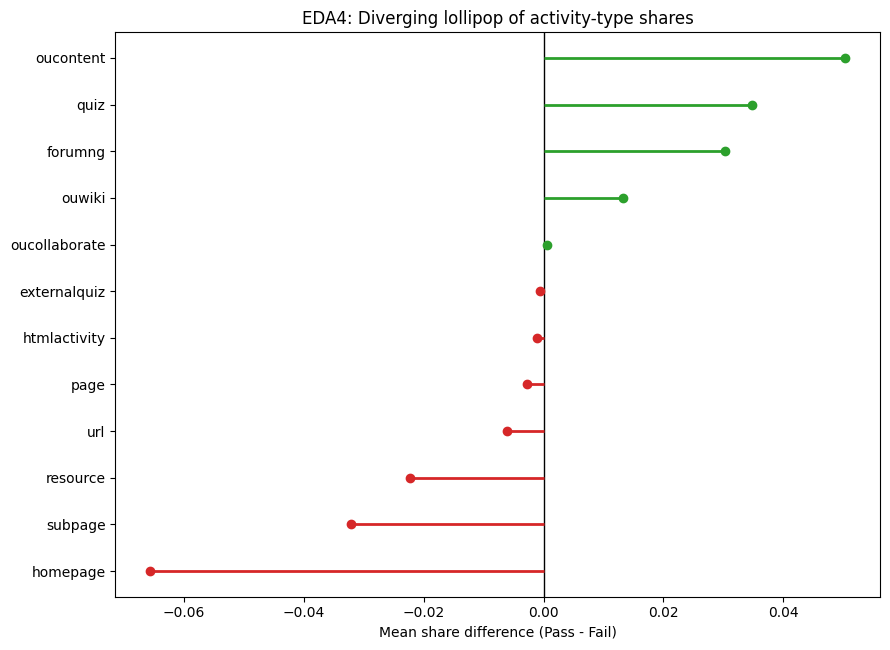

Selected activity-share differences:
                  feature  mean_pass  mean_fail  diff_pass_minus_fail
     clicks_type_homepage     0.2044     0.2700               -0.0657
      clicks_type_subpage     0.0906     0.1227               -0.0321
     clicks_type_resource     0.0397     0.0621               -0.0224
          clicks_type_url     0.0165     0.0225               -0.0061
         clicks_type_page     0.0009     0.0036               -0.0027
 clicks_type_htmlactivity     0.0001     0.0012               -0.0011
 clicks_type_externalquiz     0.0023     0.0029               -0.0006
clicks_type_oucollaborate     0.0034     0.0027                0.0006
       clicks_type_ouwiki     0.0240     0.0108                0.0133
      clicks_type_forumng     0.1796     0.1493                0.0302
         clicks_type_quiz     0.1698     0.1349                0.0348
    clicks_type_oucontent     0.2635     0.2131                0.0503


In [12]:
# --- EDA 4: Style/composition shares with diverging lollipop
click_cols_eda4 = [c for c in final_data.columns if c.startswith('clicks_type_')]
eda_share_df = None

if not click_cols_eda4:
    print('skip EDA4: no clicks_type_* columns found.')
else:
    d = final_data[[EDA_TARGET] + click_cols_eda4].copy()
    d = d[d[EDA_TARGET].isin([0, 1])]

    total_type_clicks = d[click_cols_eda4].sum(axis=1)
    shares = d[click_cols_eda4].div(total_type_clicks.replace(0, np.nan), axis=0)
    shares[EDA_TARGET] = d[EDA_TARGET].values

    valid_rows = shares[click_cols_eda4].notna().any(axis=1).sum()
    if valid_rows < 50:
        print(f'skip EDA4: too few rows with valid shares (n={valid_rows}).')
    else:
        mean_pass = shares.loc[shares[EDA_TARGET] == 1, click_cols_eda4].mean(skipna=True)
        mean_fail = shares.loc[shares[EDA_TARGET] == 0, click_cols_eda4].mean(skipna=True)
        diff = mean_pass - mean_fail

        t = pd.DataFrame({
            'feature': diff.index,
            'mean_pass': mean_pass.values,
            'mean_fail': mean_fail.values,
            'diff_pass_minus_fail': diff.values
        }).dropna(subset=['diff_pass_minus_fail'])

        if t.empty:
            print('skip EDA4: no valid style differences after filtering.')
        else:
            top = t.reindex(t['diff_pass_minus_fail'].abs().sort_values(ascending=False).index).head(12).copy()
            top = top.sort_values('diff_pass_minus_fail')

            y = np.arange(len(top))
            vals = top['diff_pass_minus_fail'].values
            cols = ['#2ca02c' if v >= 0 else '#d62728' for v in vals]

            plt.figure(figsize=(9, max(4, 0.45 * len(top) + 1.2)))
            plt.axvline(0, color='black', linewidth=1)
            for yi, v, c in zip(y, vals, cols):
                plt.hlines(yi, 0, v, color=c, linewidth=2)
                plt.plot(v, yi, 'o', color=c)
            plt.yticks(y, [s.replace('clicks_type_', '') for s in top['feature'].tolist()])
            plt.xlabel('Mean share difference (Pass - Fail)')
            plt.title('EDA4: Diverging lollipop of activity-type shares')
            plt.tight_layout()
            plt.show()

            print('Selected activity-share differences:')
            print(top[['feature', 'mean_pass', 'mean_fail', 'diff_pass_minus_fail']].round(4).to_string(index=False))

            eda_share_df = shares.copy()
            eda_summary['eda4_top_diff'] = top.copy()


### EDA 5 - Diversity (Entropy and Top-Type Share)


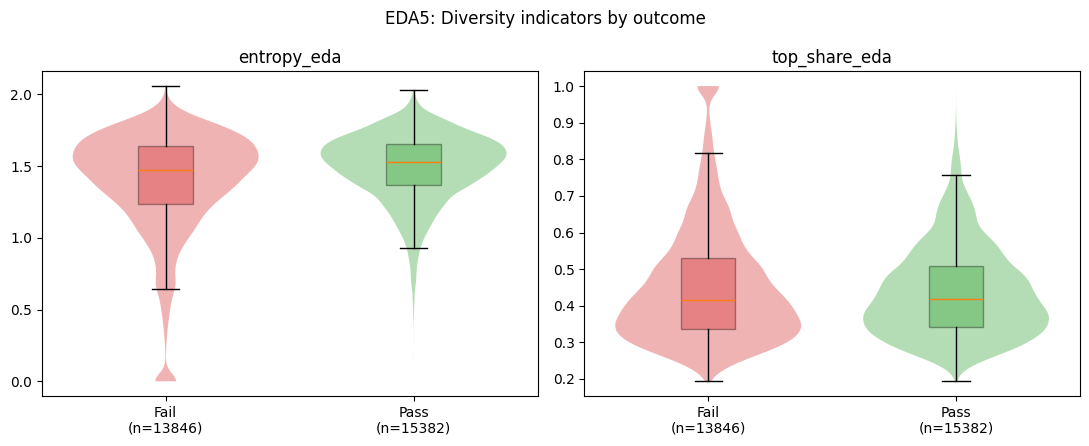

Diversity summary by outcome (mean/median):
                         entropy_eda         top_share_eda        
                                mean  median          mean  median
final_result_upd_numeric                                          
0                             1.3865  1.4701        0.4534  0.4154
1                             1.4912  1.5279        0.4365  0.4176


In [13]:
# --- EDA 5: Diversity via entropy and top-type share from share matrix
if 'eda_share_df' not in locals() or eda_share_df is None or len(eda_share_df) == 0:
    print('skip EDA5: share_df unavailable (EDA4 did not run).')
else:
    share_cols = [c for c in eda_share_df.columns if c.startswith('clicks_type_')]
    if not share_cols:
        print('skip EDA5: no share columns present.')
    else:
        eps = 1e-12
        entropy_eda = -(eda_share_df[share_cols] * np.log(eda_share_df[share_cols] + eps)).sum(axis=1)
        top_share_eda = eda_share_df[share_cols].max(axis=1)

        d = pd.DataFrame({EDA_TARGET: eda_share_df[EDA_TARGET], 'entropy_eda': entropy_eda, 'top_share_eda': top_share_eda})
        d = d[d[EDA_TARGET].isin([0, 1])].replace([np.inf, -np.inf], np.nan)
        d = d.dropna(subset=['entropy_eda', 'top_share_eda'])

        if len(d) < 50 or d[EDA_TARGET].nunique() < 2:
            print(f'skip EDA5: insufficient rows/classes (n={len(d)}, classes={d[EDA_TARGET].nunique()}).')
        else:
            fail_ent = d.loc[d[EDA_TARGET] == 0, 'entropy_eda']
            pass_ent = d.loc[d[EDA_TARGET] == 1, 'entropy_eda']
            fail_top = d.loc[d[EDA_TARGET] == 0, 'top_share_eda']
            pass_top = d.loc[d[EDA_TARGET] == 1, 'top_share_eda']

            fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
            for ax, a, b, title in [(axes[0], fail_ent, pass_ent, 'entropy_eda'), (axes[1], fail_top, pass_top, 'top_share_eda')]:
                vp = ax.violinplot([a.values, b.values], positions=[1, 2], widths=0.75, showmeans=False, showextrema=False)
                for body, c in zip(vp['bodies'], ['#d62728', '#2ca02c']):
                    body.set_facecolor(c); body.set_alpha(0.35)
                bx = ax.boxplot([a.values, b.values], positions=[1, 2], widths=0.22, patch_artist=True, showfliers=False)
                for p, c in zip(bx['boxes'], ['#d62728', '#2ca02c']):
                    p.set_facecolor(c); p.set_alpha(0.35)
                ax.set_xticks([1, 2])
                ax.set_xticklabels([f'Fail\n(n={len(a)})', f'Pass\n(n={len(b)})'])
                ax.set_title(title)

            plt.suptitle('EDA5: Diversity indicators by outcome')
            plt.tight_layout()
            plt.show()

            stats = d.groupby(EDA_TARGET)[['entropy_eda', 'top_share_eda']].agg(['mean', 'median'])
            print('Diversity summary by outcome (mean/median):')
            print(stats.round(4).to_string())
            eda_summary['eda5_stats'] = stats.copy()


### EDA 6 - Timing by Day (0-30) with Student-Day Aggregation


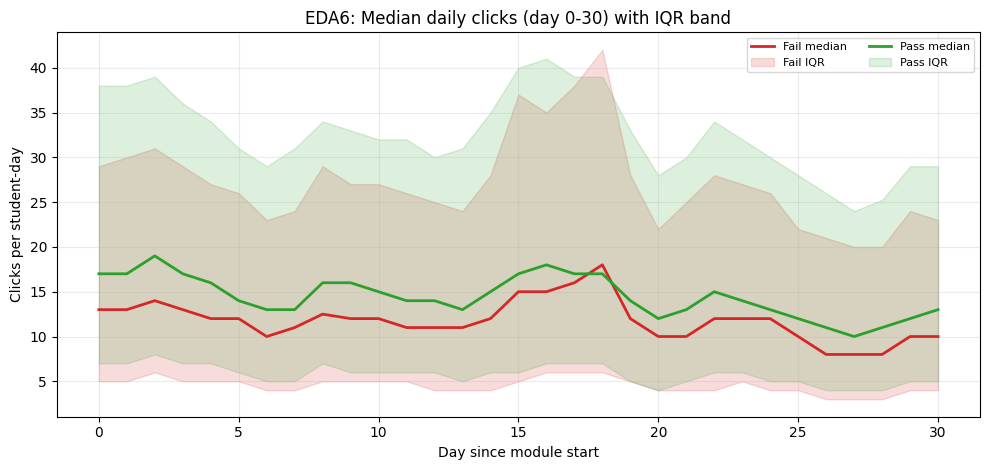

Note: descriptive pattern only, not causal evidence.


In [14]:
# --- EDA 6: Timing by day 0-30 with student-day aggregation
eda6_ran = False
req_sv = {'id_student', 'code_module', 'code_presentation', 'date', 'sum_click'}
req_si = {'id_student', 'code_module', 'code_presentation', EDA_TARGET}

if 'student_vle' not in globals() or 'student_info' not in globals():
    print('skip EDA6: student_vle/student_info objects are not available.')
elif not req_sv.issubset(set(student_vle.columns)):
    print(f"skip EDA6: student_vle missing columns {sorted(req_sv - set(student_vle.columns))}")
elif not req_si.issubset(set(student_info.columns)):
    print(f"skip EDA6: student_info missing columns {sorted(req_si - set(student_info.columns))}")
else:
    keys = ['id_student', 'code_module', 'code_presentation']
    sv = student_vle[keys + ['date', 'sum_click']].copy()
    sv['date'] = pd.to_numeric(sv['date'], errors='coerce')
    sv['sum_click'] = pd.to_numeric(sv['sum_click'], errors='coerce')
    sv = sv.dropna(subset=['date', 'sum_click'])
    sv = sv[sv['date'].between(0, 30)].copy()

    out_map = student_info[keys + [EDA_TARGET]].drop_duplicates().copy()
    out_map = out_map[out_map[EDA_TARGET].isin([0, 1])]

    merged = sv.merge(out_map, on=keys, how='inner')
    if len(merged) < 200:
        print(f'skip EDA6: too few merged rows (n={len(merged)}).')
    else:
        student_day = (
            merged.groupby(keys + [EDA_TARGET, 'date'], observed=True, as_index=False)
                  .agg(student_day_clicks=('sum_click', 'sum'))
        )
        if len(student_day) < 80:
            print(f'skip EDA6: too few student-day rows (n={len(student_day)}).')
        else:
            day_curve = (
                student_day.groupby([EDA_TARGET, 'date'], observed=True)['student_day_clicks']
                           .agg(median='median', mean='mean', q25=lambda s: s.quantile(0.25), q75=lambda s: s.quantile(0.75))
                           .reset_index()
            )
            if day_curve.empty:
                print('skip EDA6: day curve is empty.')
            else:
                plt.figure(figsize=(10, 4.8))
                drawn = 0
                for cls, lab, col in [(0, 'Fail', '#d62728'), (1, 'Pass', '#2ca02c')]:
                    sub = day_curve[day_curve[EDA_TARGET] == cls].sort_values('date')
                    if sub.empty:
                        continue
                    plt.plot(sub['date'], sub['median'], color=col, linewidth=2, label=f'{lab} median')
                    plt.fill_between(sub['date'], sub['q25'], sub['q75'], color=col, alpha=0.16, label=f'{lab} IQR')
                    drawn += 1
                if drawn == 0:
                    print('skip EDA6: no class-specific curves available.')
                    plt.close()
                else:
                    plt.title('EDA6: Median daily clicks (day 0-30) with IQR band')
                    plt.xlabel('Day since module start')
                    plt.ylabel('Clicks per student-day')
                    plt.grid(alpha=0.25)
                    plt.legend(fontsize=8, ncol=2)
                    plt.tight_layout()
                    plt.show()
                    print('Note: descriptive pattern only, not causal evidence.')
                    eda6_ran = True
                    eda_summary['eda6_day_curve'] = day_curve.copy()


### EDA 7 - Confounder Context (module/education/imd_band)


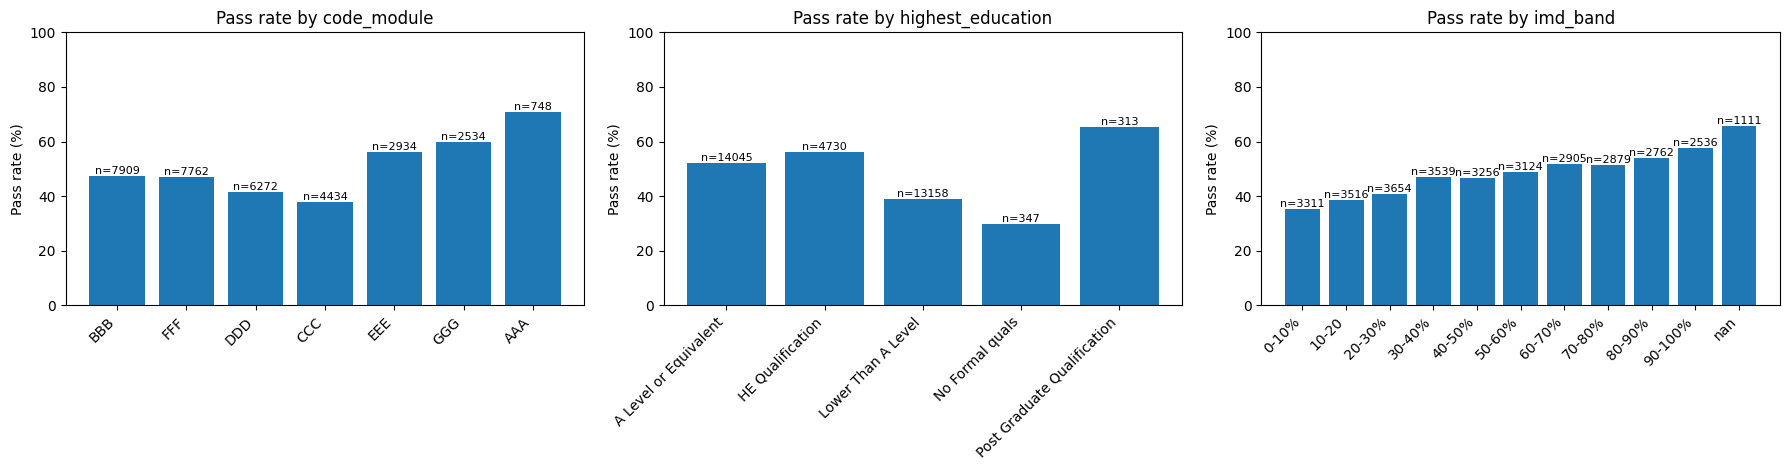


code_module context table (n and pass rate %):
code_module    n  pass_rate_pct
        BBB 7909          47.46
        FFF 7762          47.00
        DDD 6272          41.61
        CCC 4434          37.84
        EEE 2934          56.24
        GGG 2534          59.75
        AAA  748          70.99

highest_education context table (n and pass rate %):
          highest_education     n  pass_rate_pct
      A Level or Equivalent 14045          52.03
           HE Qualification  4730          56.17
         Lower Than A Level 13158          38.85
            No Formal quals   347          29.68
Post Graduate Qualification   313          65.50

imd_band context table (n and pass rate %):
imd_band    n  pass_rate_pct
   0-10% 3311          35.16
   10-20 3516          38.62
  20-30% 3654          40.75
  30-40% 3539          46.91
  40-50% 3256          46.59
  50-60% 3124          48.78
  60-70% 2905          51.91
  70-80% 2879          51.51
  80-90% 2762          54.06
 90-100% 2536

In [15]:
# --- EDA 7: Confounder context with pass rates and counts
conf_cols = ['code_module', 'highest_education', 'imd_band']
eda7_tables = {}
plot_parts = []

for col in conf_cols:
    if col not in final_data.columns:
        print(f'skip EDA7 ({col}): column missing.')
        continue

    d = final_data[[col, EDA_TARGET]].copy()
    d = d[d[EDA_TARGET].isin([0, 1])]
    d[col] = d[col].astype(str).fillna('Missing')

    g = d.groupby(col, dropna=False, as_index=False).agg(n=(EDA_TARGET, 'size'), pass_rate=(EDA_TARGET, 'mean'))

    if col == 'code_module':
        g = g.sort_values('n', ascending=False).head(10)
    elif col == 'imd_band':
        def imd_key(x):
            s = str(x)
            digs = ''.join(ch for ch in s if ch.isdigit())
            return int(digs[:2]) if digs else 999
        g['__k'] = g[col].map(imd_key)
        g = g.sort_values(['__k', col]).drop(columns='__k')

    g['pass_rate_pct'] = g['pass_rate'] * 100
    eda7_tables[col] = g.copy()
    if len(g):
        plot_parts.append((col, g.copy()))

if not plot_parts:
    print('skip EDA7: no confounder summaries to plot.')
else:
    fig, axes = plt.subplots(1, len(plot_parts), figsize=(6 * len(plot_parts), 4.8))
    if len(plot_parts) == 1:
        axes = [axes]

    for ax, (col, g) in zip(axes, plot_parts):
        x = np.arange(len(g))
        bars = ax.bar(x, g['pass_rate_pct'].values)
        ax.set_title(f'Pass rate by {col}')
        ax.set_ylabel('Pass rate (%)')
        ax.set_ylim(0, 100)
        ax.set_xticks(x)
        ax.set_xticklabels(g[col].astype(str).tolist(), rotation=45, ha='right')
        for b, n in zip(bars, g['n']):
            ax.text(b.get_x() + b.get_width()/2, b.get_height(), f'n={int(n)}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

    for col, g in eda7_tables.items():
        print(f'\n{col} context table (n and pass rate %):')
        print(g[[col, 'n', 'pass_rate_pct']].round(2).to_string(index=False))

    eda_summary['eda7_tables'] = eda7_tables


### EDA 8 - Univariate Logistic OR Forest Plot + Final Summary/Caveats


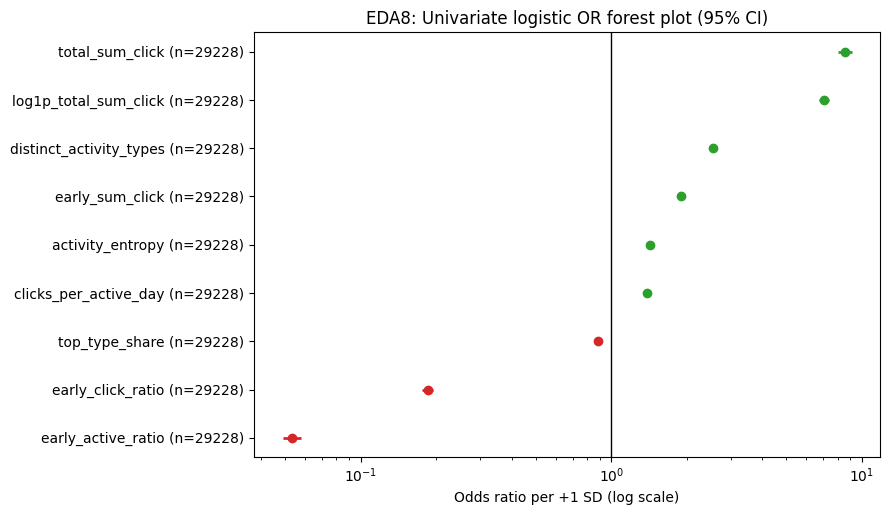

Top univariate OR results:
                feature     n    beta     or  ci_low  ci_high
     early_active_ratio 29228 -2.9351 0.0531  0.0488   0.0578
      early_click_ratio 29228 -1.6887 0.1848  0.1756   0.1943
         top_type_share 29228 -0.1194 0.8874  0.8672   0.9082
  clicks_per_active_day 29228  0.3308 1.3920  1.3568   1.4281
       activity_entropy 29228  0.3581 1.4305  1.3951   1.4669
        early_sum_click 29228  0.6379 1.8925  1.8277   1.9597
distinct_activity_types 29228  0.9387 2.5565  2.4790   2.6365
  log1p_total_sum_click 29228  1.9521 7.0438  6.7169   7.3865
        total_sum_click 29228  2.1440 8.5332  8.0093   9.0913
Summary/Caveats:
- Intensity: average total clicks are higher in Pass than Fail.
- Dose-response: quartile pass rate moves from 9.9% to 87.2% from lowest to highest engagement.
- Style/composition: 'homepage' has one of the largest Pass-Fail share gaps.
- Diversity: entropy is higher in Pass than Fail.
- Timing: student-day curves indicate different d

In [16]:
# --- EDA 8: Univariate logistic OR forest plot + summary/caveats
cand = [
    'total_sum_click', 'early_sum_click', 'clicks_per_active_day',
    'early_click_ratio', 'early_active_ratio', 'distinct_activity_types',
    'activity_entropy', 'top_type_share', 'log1p_total_sum_click'
]
cand = [c for c in cand if c in final_data.columns and pd.api.types.is_numeric_dtype(final_data[c])]

rows = []
for feat in cand:
    try:
        d = final_data[[feat, EDA_TARGET]].copy()
        d[feat] = pd.to_numeric(d[feat], errors='coerce')
        d = d[d[EDA_TARGET].isin([0, 1])].dropna(subset=[feat])
        if len(d) < 50:
            print(f"EDA8 skip '{feat}': too few rows (n={len(d)}).")
            continue
        if d[EDA_TARGET].nunique() < 2:
            print(f"EDA8 skip '{feat}': one target class after filtering.")
            continue

        x = d[feat].to_numpy(float)
        y = d[EDA_TARGET].to_numpy(int)
        sd = np.std(x)
        if (not np.isfinite(sd)) or sd == 0:
            print(f"EDA8 skip '{feat}': zero/invalid std.")
            continue
        xz = (x - np.mean(x)) / sd

        lr = LogisticRegression(solver='lbfgs', C=1e6, max_iter=2000)
        lr.fit(xz.reshape(-1, 1), y)
        beta = float(lr.coef_[0, 0])

        p = lr.predict_proba(xz.reshape(-1, 1))[:, 1]
        W = p * (1 - p)
        Xd = np.column_stack([np.ones(len(xz)), xz])
        I = Xd.T @ (W[:, None] * Xd)
        cov = np.linalg.pinv(I)
        se = float(np.sqrt(max(cov[1, 1], 0)))
        if (not np.isfinite(se)) or se <= 0:
            print(f"EDA8 skip '{feat}': invalid SE.")
            continue

        rows.append({
            'feature': feat, 'n': len(d), 'beta': beta,
            'or': float(np.exp(beta)),
            'ci_low': float(np.exp(beta - 1.96 * se)),
            'ci_high': float(np.exp(beta + 1.96 * se)),
            'abs_beta': abs(beta)
        })
    except Exception as e:
        print(f"EDA8 skip '{feat}' due to fit issue: {type(e).__name__}: {e}")

or_df = pd.DataFrame(rows)
if len(or_df) >= 3:
    top = or_df.sort_values('abs_beta', ascending=False).head(12).sort_values('or')
    y = np.arange(len(top))
    plt.figure(figsize=(9, max(4, 0.45 * len(top) + 1.2)))
    plt.axvline(1.0, color='black', linewidth=1)
    for yi, (_, r) in enumerate(top.iterrows()):
        c = '#2ca02c' if r['or'] >= 1 else '#d62728'
        plt.hlines(yi, r['ci_low'], r['ci_high'], color=c, linewidth=2)
        plt.plot(r['or'], yi, 'o', color=c)
    plt.yticks(y, [f"{f} (n={int(n)})" for f, n in zip(top['feature'], top['n'])])
    plt.xscale('log')
    plt.xlabel('Odds ratio per +1 SD (log scale)')
    plt.title('EDA8: Univariate logistic OR forest plot (95% CI)')
    plt.tight_layout(); plt.show()
    print('Top univariate OR results:')
    print(top[['feature', 'n', 'beta', 'or', 'ci_low', 'ci_high']].round(4).to_string(index=False))
    eda_summary['eda8_or_top'] = top.copy()
else:
    print('EDA8 fallback: <3 logistic fits succeeded, using correlation ranking.')
    b = final_data[cand + [EDA_TARGET]].copy().dropna() if cand else pd.DataFrame()
    if b.empty:
        print('EDA8 fallback skipped: no complete cases for correlation backup.')
    else:
        corr = b.corr(numeric_only=True)[EDA_TARGET].drop(EDA_TARGET).sort_values(key=lambda s: s.abs(), ascending=False).head(12)
        plt.figure(figsize=(8, max(4, 0.4 * len(corr) + 1.2)))
        plt.barh(corr.index[::-1], corr.values[::-1], color=['#2ca02c' if v > 0 else '#d62728' for v in corr.values[::-1]])
        plt.axvline(0, color='black', linewidth=1)
        plt.title('EDA8 fallback: correlation ranking')
        plt.xlabel('Correlation with target')
        plt.tight_layout(); plt.show()
        print(corr.round(4).to_string())
        eda_summary['eda8_fallback_corr'] = corr.copy()

# Summary/Caveats (5-7 bullets)
summary = []
if 'total_sum_click' in final_data.columns:
    s = final_data[[EDA_TARGET, 'total_sum_click']].dropna(); s = s[s[EDA_TARGET].isin([0, 1])]
    if len(s) and s[EDA_TARGET].nunique() == 2:
        summary.append(f"Intensity: average total clicks are {'higher' if s.loc[s[EDA_TARGET]==1,'total_sum_click'].mean() >= s.loc[s[EDA_TARGET]==0,'total_sum_click'].mean() else 'lower'} in Pass than Fail.")
q = eda_summary.get('eda3_quartiles', pd.DataFrame()) if isinstance(eda_summary, dict) else pd.DataFrame()
summary.append(f"Dose-response: quartile pass rate moves from {float(q.iloc[0]['pass_rate'])*100:.1f}% to {float(q.iloc[-1]['pass_rate'])*100:.1f}% from lowest to highest engagement." if isinstance(q, pd.DataFrame) and len(q) >= 2 else 'Dose-response: quartile/decile trend could not be estimated reliably.')
t = eda_summary.get('eda4_top_diff', pd.DataFrame()) if isinstance(eda_summary, dict) else pd.DataFrame()
if isinstance(t, pd.DataFrame) and len(t):
    r = t.reindex(t['diff_pass_minus_fail'].abs().sort_values(ascending=False).index).iloc[0]
    summary.append(f"Style/composition: '{str(r['feature']).replace('clicks_type_', '')}' has one of the largest Pass-Fail share gaps.")
else:
    summary.append('Style/composition: share differences were limited by available data.')
dv = eda_summary.get('eda5_stats', pd.DataFrame()) if isinstance(eda_summary, dict) else pd.DataFrame()
if isinstance(dv, pd.DataFrame) and len(dv):
    try:
        summary.append(f"Diversity: entropy is {'higher' if float(dv.loc[1, ('entropy_eda','mean')]) >= float(dv.loc[0, ('entropy_eda','mean')]) else 'lower'} in Pass than Fail.")
    except Exception:
        summary.append('Diversity: entropy/top-share computed, but class comparison was unstable.')
else:
    summary.append('Diversity: entropy/top-share analysis was skipped or underpowered.')
summary.append('Timing: student-day curves indicate different day-0-30 patterns.' if ('eda6_ran' in locals() and eda6_ran) else 'Timing: day-0-30 curve was skipped due to missing/sparse prerequisites.')
summary.append('Caveat: global dropna can bias comparisons; coverage gaps by outcome should be reviewed before interpretation.')
summary.append('Caveat: module/education/IMD confounding remains possible, and these findings are descriptive rather than causal.')

print('Summary/Caveats:')
for line in summary[:7]:
    print(f'- {line}')


## Prep for Training
We keep the agreed feature set, apply stable preprocessing, and prepare one modeling-ready dataset.

Why it matters: consistent preprocessing lets us compare models fairly.


In [17]:
# --- Apply final feature list (no external CSV)
TARGET = 'final_result_upd_numeric'
FINAL_FEATURES = [
    'highest_education','imd_band','age_band','num_of_prev_attempts','studied_credits','disability',
    'clicks_per_active_day','clicks_type_dataplus','clicks_type_dualpane','clicks_type_externalquiz',
    'clicks_type_folder','clicks_type_forumng','clicks_type_glossary','clicks_type_homepage',
    'clicks_type_htmlactivity','clicks_type_oucollaborate','clicks_type_oucontent',
    'clicks_type_ouelluminate','clicks_type_ouwiki','clicks_type_page','clicks_type_questionnaire',
    'clicks_type_quiz','clicks_type_repeatactivity','clicks_type_resource','clicks_type_sharedsubpage',
    'clicks_type_subpage','clicks_type_url','distinct_activity_types','activity_entropy','top_type_share',
    'registered_early_flag','registration_lead_days',

    # Engagement signals
    'total_sum_click','active_days','distinct_sites','early_sum_click','early_active_days',
    'early_click_ratio','early_clicks_per_active_day','early_active_ratio',
    'log1p_total_sum_click','log1p_early_sum_click',

    # Context signals
    'module_presentation_length','date_registration','has_exam','has_non_exam'
]

missing = [f for f in FINAL_FEATURES if f not in final_data.columns]
if missing:
    print('Missing features (not found in dataset):', missing)

FINAL_FEATURES = [f for f in FINAL_FEATURES if f in final_data.columns]

# Safety check: remove obviously leakage-prone columns if present
leak_terms = ['final_result', 'final', 'result', 'overall_grade', 'mean_score', 'score', 'grade', 'late_submissions', 'date_unregistration']
leak_like = [f for f in FINAL_FEATURES if any(t in f.lower() for t in leak_terms)]
if leak_like:
    print('Leak-like features removed:', leak_like)
    FINAL_FEATURES = [f for f in FINAL_FEATURES if f not in leak_like]

model_data = final_data[FINAL_FEATURES + [TARGET]].copy()

# Outlier capping on numeric features (1st/99th percentile)
num_cols = model_data[FINAL_FEATURES].select_dtypes(include=['number']).columns.tolist()
for c in num_cols:
    low, high = model_data[c].quantile([0.01, 0.99])
    model_data[c] = model_data[c].clip(lower=low, upper=high)

X = model_data[FINAL_FEATURES]
y = model_data[TARGET].astype(int)

# Column types for preprocessing
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

# Preprocessing pipeline
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=True)

preprocess = ColumnTransformer([
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', ohe)
    ]), cat_cols)
])

prep_summary = pd.DataFrame([
    {'item': 'rows for modeling', 'value': len(X)},
    {'item': 'features used', 'value': len(FINAL_FEATURES)},
    {'item': 'numeric features', 'value': len(num_cols)},
    {'item': 'categorical features', 'value': len(cat_cols)}
])
print(prep_summary.to_string(index=False))


                item  value
   rows for modeling  32593
       features used     46
    numeric features     42
categorical features      4


## Algorithm Principles (Plain Summary)

- **Logistic Regression:** simple linear baseline with clear interpretation.
- **Decision Tree:** rule-based model that captures non-linear splits.
- **H2O AutoML:** automated search across strong model families.
- **XGBoost + Optuna:** boosted trees with tuned hyperparameters for strong tabular performance.


## Modeling
We split data into 80% train, 10% validation, and 10% test.
- Train: fit model parameters.
- Validation: tune model/hyperparameters.
- Test: final unbiased comparison of all 4 models.


In [18]:
# 80/10/10 split shared across all models
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

split_summary = pd.DataFrame([
    {'split': 'train', 'rows': len(X_train), 'ratio': round(len(X_train) / len(X), 3)},
    {'split': 'val', 'rows': len(X_val), 'ratio': round(len(X_val) / len(X), 3)},
    {'split': 'test', 'rows': len(X_test), 'ratio': round(len(X_test) / len(X), 3)}
])
print(split_summary.to_string(index=False))


split  rows  ratio
train 26074    0.8
  val  3259    0.1
 test  3260    0.1


### Logistic Regression (Baseline)
A simple baseline model. It helps us measure whether advanced models add clear value.


In [19]:
# --- Logistic Regression
logreg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
logreg_pipe = Pipeline(steps=[('preprocess', preprocess), ('clf', logreg)])
logreg_pipe.fit(X_train, y_train)

# Validation (for quick check)
logreg_val_prob = logreg_pipe.predict_proba(X_val)[:, 1]
logreg_val_pred = (logreg_val_prob >= 0.5).astype(int)

# Final test evaluation
logreg_prob = logreg_pipe.predict_proba(X_test)[:, 1]
logreg_pred = (logreg_prob >= 0.5).astype(int)

logreg_metrics = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, logreg_pred),
    'Precision': precision_score(y_test, logreg_pred, zero_division=0),
    'Recall': recall_score(y_test, logreg_pred, zero_division=0),
    'F1': f1_score(y_test, logreg_pred, zero_division=0),
    'AUC': roc_auc_score(y_test, logreg_prob),
    'LogLoss': log_loss(y_test, logreg_prob)
}

print('Validation AUC (LogReg):', round(roc_auc_score(y_val, logreg_val_prob), 4))
logreg_metrics


Validation AUC (LogReg): 0.9352


{'Model': 'Logistic Regression',
 'Accuracy': 0.8760736196319019,
 'Precision': 0.8740936058009229,
 'Recall': 0.8615984405458089,
 'F1': 0.8678010471204188,
 'AUC': np.float64(0.9392615547951594),
 'LogLoss': 0.32462794802441514}

### Decision Tree (Baseline)
A rule-based baseline. It captures non-linear patterns and remains easy to explain.


In [20]:
# --- Decision Tree
clf_tree = DecisionTreeClassifier(max_depth=6, random_state=42)

tree_pipe = Pipeline(steps=[('preprocess', preprocess), ('clf', clf_tree)])
tree_pipe.fit(X_train, y_train)

# Validation
if hasattr(tree_pipe, 'predict_proba'):
    tree_val_prob = tree_pipe.predict_proba(X_val)[:, 1]
else:
    tree_val_prob = None

# Final test evaluation
tree_pred = tree_pipe.predict(X_test)
tree_prob = tree_pipe.predict_proba(X_test)[:, 1] if hasattr(tree_pipe, 'predict_proba') else None

tree_metrics = {
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, tree_pred),
    'Precision': precision_score(y_test, tree_pred, zero_division=0),
    'Recall': recall_score(y_test, tree_pred, zero_division=0),
    'F1': f1_score(y_test, tree_pred, zero_division=0),
    'AUC': roc_auc_score(y_test, tree_prob) if tree_prob is not None else None,
    'LogLoss': log_loss(y_test, tree_prob) if tree_prob is not None else None
}

if tree_val_prob is not None:
    print('Validation AUC (Tree):', round(roc_auc_score(y_val, tree_val_prob), 4))

tree_metrics


Validation AUC (Tree): 0.9307


{'Model': 'Decision Tree',
 'Accuracy': 0.8779141104294479,
 'Precision': 0.8476538695917124,
 'Recall': 0.9038336582196231,
 'F1': 0.8748427672955975,
 'AUC': np.float64(0.9332397373876726),
 'LogLoss': 0.3105452341019358}

### H2O AutoML (Complex Model)
AutoML searches multiple model families and returns the best leaderboard model.


In [21]:
# --- Stage 2A: H2O AutoML (with fallback)
if H2O_READY:
    train_df = pd.concat([X_train, y_train], axis=1)
    val_df = pd.concat([X_val, y_val], axis=1)
    test_df = pd.concat([X_test, y_test], axis=1)

    h2o_train = h2o.H2OFrame(train_df)
    h2o_val = h2o.H2OFrame(val_df)
    h2o_test = h2o.H2OFrame(test_df)

    h2o_train[TARGET] = h2o_train[TARGET].asfactor()
    h2o_val[TARGET] = h2o_val[TARGET].asfactor()
    h2o_test[TARGET] = h2o_test[TARGET].asfactor()

    aml = H2OAutoML(
        max_models=AUTOML_MAX_MODELS,
        max_runtime_secs=AUTOML_MAX_RUNTIME_SECS,
        seed=42,
        sort_metric='AUC',
        nfolds=5,
        exclude_algos=['XGBoost'],
        verbosity='warn'
    )

    aml.train(
        x=FINAL_FEATURES,
        y=TARGET,
        training_frame=h2o_train,
        validation_frame=h2o_val,
        leaderboard_frame=h2o_val
    )

    leader = aml.leader

    # Validation AUC
    val_pred_df = leader.predict(h2o_val).as_data_frame()
    val_prob = pd.to_numeric(val_pred_df.get('p1', pd.Series(dtype=float)), errors='coerce')
    if len(val_prob) == len(y_val):
        print('Validation AUC (AutoML):', round(roc_auc_score(y_val, val_prob.values), 4))

    # Final test predictions and metrics
    automl_pred_df = leader.predict(h2o_test).as_data_frame()
    if 'p1' in automl_pred_df.columns:
        automl_prob = pd.to_numeric(automl_pred_df['p1'], errors='coerce').fillna(0).values
    elif 'predict' in automl_pred_df.columns:
        automl_prob = pd.to_numeric(automl_pred_df['predict'], errors='coerce').fillna(0).values
    else:
        automl_prob = None

    if automl_prob is not None:
        automl_pred = (automl_prob >= 0.5).astype(int)
        automl_metrics = {
            'Model': 'H2O AutoML (leader)',
            'Accuracy': accuracy_score(y_test, automl_pred),
            'Precision': precision_score(y_test, automl_pred, zero_division=0),
            'Recall': recall_score(y_test, automl_pred, zero_division=0),
            'F1': f1_score(y_test, automl_pred, zero_division=0),
            'AUC': roc_auc_score(y_test, automl_prob),
            'LogLoss': log_loss(y_test, automl_prob)
        }
    else:
        automl_metrics = {
            'Model': 'H2O AutoML (leader)',
            'Accuracy': None,
            'Precision': None,
            'Recall': None,
            'F1': None,
            'AUC': None,
            'LogLoss': None
        }
else:
    # Fallback to keep pipeline runnable when H2O/Java is unavailable
    fallback_pipe = Pipeline(steps=[
        ('preprocess', preprocess),
        ('clf', HistGradientBoostingClassifier(random_state=42, max_depth=6, learning_rate=0.05))
    ])
    fallback_pipe.fit(X_train, y_train)

    automl_val_prob = fallback_pipe.predict_proba(X_val)[:, 1]
    print('Validation AUC (Fallback AutoML):', round(roc_auc_score(y_val, automl_val_prob), 4))

    automl_prob = fallback_pipe.predict_proba(X_test)[:, 1]
    automl_pred = (automl_prob >= 0.5).astype(int)

    automl_metrics = {
        'Model': 'AutoML Fallback (HistGB)',
        'Accuracy': accuracy_score(y_test, automl_pred),
        'Precision': precision_score(y_test, automl_pred, zero_division=0),
        'Recall': recall_score(y_test, automl_pred, zero_division=0),
        'F1': f1_score(y_test, automl_pred, zero_division=0),
        'AUC': roc_auc_score(y_test, automl_prob),
        'LogLoss': log_loss(y_test, automl_prob)
    }

automl_metrics


Validation AUC (Fallback AutoML): 0.9584


{'Model': 'AutoML Fallback (HistGB)',
 'Accuracy': 0.9113496932515337,
 'Precision': 0.8733572281959379,
 'Recall': 0.9499675113710201,
 'F1': 0.91005291005291,
 'AUC': np.float64(0.9622048320275585),
 'LogLoss': 0.235368721162289}

### XGBoost + Optuna (Complex Model)
XGBoost is a strong boosting model. Optuna tunes key hyperparameters for better AUC.


In [22]:
# --- Stage 2B: XGBoost + Optuna (train on train, tune on val, evaluate on test)
X_train_t = preprocess.fit_transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

dtrain = xgb.DMatrix(X_train_t, label=y_train)
dval = xgb.DMatrix(X_val_t, label=y_val)
dtest = xgb.DMatrix(X_test_t, label=y_test)


def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'tree_method': 'hist',
        'device': 'cuda:0',
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
    }

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=params['n_estimators'],
        evals=[(dval, 'validation')],
        early_stopping_rounds=XGB_EARLY_STOPPING_ROUNDS,
        verbose_eval=False
    )
    y_pred_val = model.predict(dval)
    return roc_auc_score(y_val, y_pred_val)

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=XGB_TRIALS, show_progress_bar=False)

best_params = study.best_params
best_auc = study.best_value
print('Validation AUC (XGBoost):', round(best_auc, 4))

final_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'tree_method': 'hist',
    'device': 'cuda:0',
    **best_params
}

n_estimators = final_params.pop('n_estimators')
final_model = xgb.train(
    final_params,
    dtrain,
    num_boost_round=n_estimators,
    evals=[(dtrain, 'train'), (dval, 'validation')],
    early_stopping_rounds=XGB_EARLY_STOPPING_ROUNDS,
    verbose_eval=False
)

y_pred = final_model.predict(dtest)
xgb_pred = (y_pred >= 0.5).astype(int)

xgb_metrics = {
    'Model': 'XGBoost (Optuna best)',
    'Accuracy': accuracy_score(y_test, xgb_pred),
    'Precision': precision_score(y_test, xgb_pred, zero_division=0),
    'Recall': recall_score(y_test, xgb_pred, zero_division=0),
    'F1': f1_score(y_test, xgb_pred, zero_division=0),
    'AUC': roc_auc_score(y_test, y_pred),
    'LogLoss': log_loss(y_test, y_pred)
}

xgb_metrics


[I 2026-03-01 23:20:04,184] A new study created in memory with name: no-name-ba4e5916-1e01-449b-b86d-b6a35477f30d


C:\Users\ento3\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\callback.py:385: UserWarning: [23:20:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()


[I 2026-03-01 23:20:04,952] Trial 0 finished with value: 0.9630318206443921 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 613, 'min_child_weight': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'gamma': 0.2904180608409973, 'reg_alpha': 4.330880728874676, 'reg_lambda': 3.005575058716044}. Best is trial 0 with value: 0.9630318206443921.


Validation AUC (XGBoost): 0.963


{'Model': 'XGBoost (Optuna best)',
 'Accuracy': 0.9239263803680982,
 'Precision': 0.8924012158054712,
 'Recall': 0.9538661468486029,
 'F1': 0.9221105527638191,
 'AUC': np.float64(0.9675880147352262),
 'LogLoss': 0.20761241187439256}

## Evaluation and Discussion
We compare model metrics and then check whether model evidence supports the EDA VLE impact story.


                   Model    AUC     F1  Accuracy  Precision  Recall  LogLoss
   XGBoost (Optuna best) 0.9676 0.9221    0.9239     0.8924  0.9539   0.2076
AutoML Fallback (HistGB) 0.9622 0.9101    0.9113     0.8734  0.9500   0.2354
     Logistic Regression 0.9393 0.8678    0.8761     0.8741  0.8616   0.3246
           Decision Tree 0.9332 0.8748    0.8779     0.8477  0.9038   0.3105

Best model by test AUC: XGBoost (Optuna best) (AUC=0.9676)


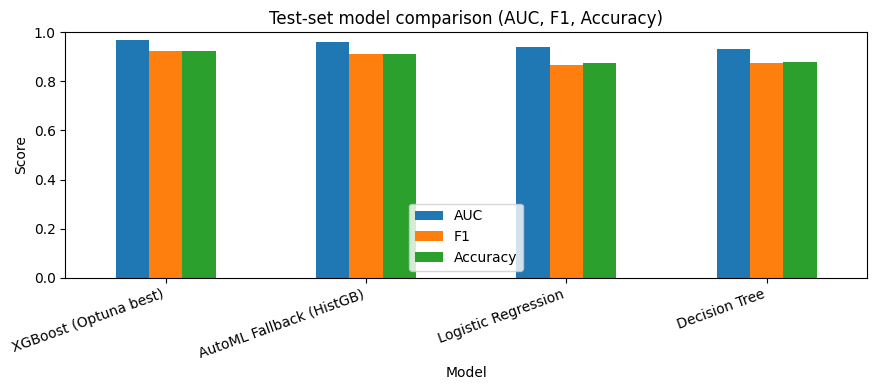

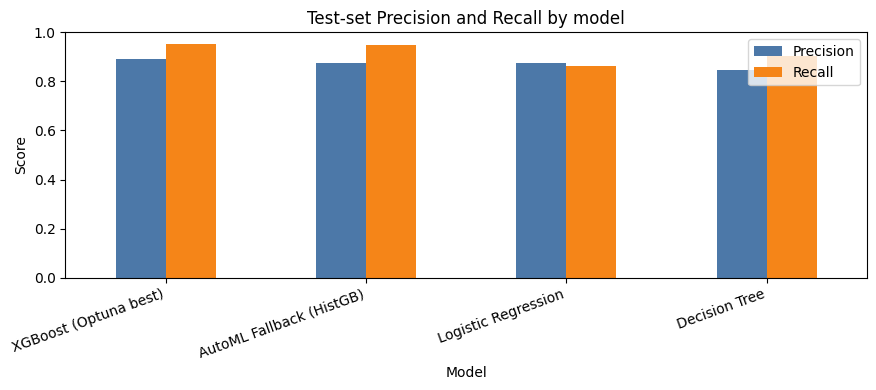

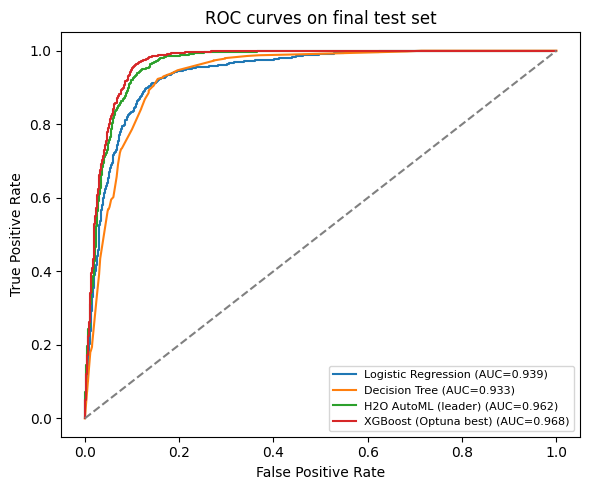

In [23]:
# --- Consolidated final test results (4 models)
all_results = [logreg_metrics, tree_metrics, automl_metrics, xgb_metrics]
results_df = pd.DataFrame(all_results)

# Keep only rows with valid AUC, then rank
results_df = results_df.dropna(subset=['AUC']).sort_values('AUC', ascending=False).reset_index(drop=True)
assert len(results_df) == 4, f'Expected 4 evaluated models, got {len(results_df)}'

print(results_df[['Model','AUC','F1','Accuracy','Precision','Recall','LogLoss']].round(4).to_string(index=False))

best_model_name = results_df.loc[0, 'Model']
best_model_auc = results_df.loc[0, 'AUC']
print(f"\nBest model by test AUC: {best_model_name} (AUC={best_model_auc:.4f})")

# Graph 1: AUC/F1/Accuracy comparison
plot_df = results_df[['Model','AUC','F1','Accuracy']].set_index('Model')
ax = plot_df.plot(kind='bar', figsize=(9,4))
ax.set_title('Test-set model comparison (AUC, F1, Accuracy)')
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Graph 2: Precision/Recall comparison (to monitor overly perfect values)
pr_df = results_df[['Model','Precision','Recall']].set_index('Model')
ax = pr_df.plot(kind='bar', figsize=(9,4), color=['#4C78A8', '#F58518'])
ax.set_title('Test-set Precision and Recall by model')
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Graph 3: ROC curves on test set
roc_inputs = [
    ('Logistic Regression', logreg_prob),
    ('Decision Tree', tree_prob),
    ('H2O AutoML (leader)', automl_prob),
    ('XGBoost (Optuna best)', y_pred)
]

plt.figure(figsize=(6,5))
for name, prob in roc_inputs:
    if prob is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.title('ROC curves on final test set')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Conclusion

Main answer to the question:
- Students with stronger and more consistent VLE engagement tend to have better pass outcomes.
- Sparse or late engagement patterns are linked to higher risk.
- Model results support the same direction seen in EDA, so the impact story is consistent.


## Short Rubric Check
- Clear question: VLE impact on performance.
- Clean data and focused feature engineering.
- Multiple models compared on the same split.
- Metrics and visuals used to support a clear conclusion.
